# Chest X-Ray Classification

## Project Overview

This project explores and compares multiple deep learning approaches for multi-class classification of chest X-ray images.

The objective is to classify each chest X-ray into one of three categories:

- **Normal**
- **Bacterial Pneumonia**
- **Viral Pneumonia**

The project uses the Chest X-Ray Pneumonia dataset from Kaggle, with images resized to **224 × 224 pixels** and models implemented using **TensorFlow/Keras**.

Three deep learning approaches are implemented and evaluated:

1. **Custom Convolutional Neural Network (CNN)** trained from scratch.
2. **EfficientNetB0 Transfer Learning** using a pretrained ImageNet backbone with frozen and fine-tuned training stages.
3. **Patch-Based Bidirectional GRU** that represents each image as a sequence of patches.

The models are evaluated using training and validation behavior, test accuracy, confusion matrices, precision, recall, and F1-score.

> **Disclaimer:** This project is intended for educational and research purposes only. It is not a medical diagnostic system and should not be used for clinical decision-making.

## Project Setup and Data Acquisition

This section prepares the project environment by importing the required libraries and downloading the Chest X-Ray Pneumonia dataset from Kaggle.

The implementation uses:

- **TensorFlow/Keras** for deep learning model development.
- **NumPy and Pandas** for numerical and tabular data processing.
- **Matplotlib and Seaborn** for visualization.
- **scikit-learn** for dataset splitting, class weighting, and evaluation metrics.
- **kagglehub** for downloading the dataset.

In [1]:
%%capture
!pip install ipython-autotime
%load_ext autotime

time: 532 µs (started: 2026-09-28 18:36:55 +00:00)


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import tensorflow as tf
import kagglehub
import gc
import gdown

from tensorflow import keras
from os import path
from tensorflow.keras import layers , models , optimizers , regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.utils import load_img, img_to_array
from sklearn import metrics
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from prompt_toolkit import history
from google.colab import files
from PIL import Image


time: 11.3 s (started: 2026-09-28 18:36:55 +00:00)


## Output Configuration

Project outputs are stored in local directories rather than user-specific cloud-storage paths.

The notebook automatically creates:

- `outputs/models/` for trained model files.
- `outputs/results/` for generated evaluation outputs.

This keeps the notebook portable across Google Colab, Jupyter, and local Python environments.

In [3]:
from pathlib import Path

# Project output directories
OUTPUT_DIR = Path("outputs")
MODEL_DIR = OUTPUT_DIR / "models"
RESULTS_DIR = OUTPUT_DIR / "results"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Models will be saved to: {MODEL_DIR.resolve()}")
print(f"Results will be saved to: {RESULTS_DIR.resolve()}")

Models will be saved to: /content/outputs/models
Results will be saved to: /content/outputs/results
time: 5.04 ms (started: 2026-09-28 18:37:06 +00:00)


## Download Dataset from Kaggle

The dataset is downloaded programmatically using `kagglehub`, which keeps the repository lightweight and avoids storing the image dataset directly in GitHub.

In [4]:
dataset_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print(f"Dataset stored at: {dataset_path}")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset stored at: /kaggle/input/chest-xray-pneumonia
time: 5.14 s (started: 2026-09-28 18:37:06 +00:00)


## Data Organization and Labeling

The original dataset organizes images into two main folders: **NORMAL** and **PNEUMONIA**.

For this project, pneumonia images are further divided into two categories based on their filenames:

- Images containing `bacteria` are labeled **Bacterial**.
- Images containing `virus` are labeled **Viral**.
- Images from the `NORMAL` folder are labeled **Normal**.

This produces the three-class classification problem used throughout the project:

1. Normal
2. Bacterial Pneumonia
3. Viral Pneumonia

In [5]:
base_dir = dataset_path

def get_data_paths(subset):
    path = os.path.join(base_dir, 'chest_xray', subset)
    data = []
    for folder in ['NORMAL', 'PNEUMONIA']:
        folder_path = os.path.join(path, folder)
        for img_path in glob.glob(os.path.join(folder_path, '*.jpeg')):
            filename = os.path.basename(img_path).lower()
            if 'normal' in folder.lower():
                label = 'Normal'
            elif 'bacteria' in filename:
                label = 'Bacterial'
            elif 'virus' in filename:
                label = 'Viral'
            else:
                continue
            data.append((img_path, label))
    return pd.DataFrame(data, columns=['image_path', 'label'])


time: 5.33 ms (started: 2026-09-28 18:37:11 +00:00)


### Dataset Splitting Strategy

The original training and validation subsets are combined to increase the amount of data available for model development.

A new stratified split is then created from the combined data:

- **80%** for training
- **20%** for validation

Stratification preserves the relative distribution of the Normal, Bacterial, and Viral classes across both subsets.

The original test set is kept completely separate and is not used during training or validation. This provides an independent dataset for final model evaluation.

In [6]:
orig_train_df = get_data_paths('train')
orig_val_df = get_data_paths('val')
test_df = get_data_paths('test')

full_train_df = pd.concat([orig_train_df, orig_val_df], axis=0).reset_index(drop=True)

train_df, val_df = train_test_split(
    full_train_df,
    test_size=0.20,
    random_state=42,
    stratify=full_train_df['label']
)

print(f"Combined data split into:/n {len(train_df)} Training and {len(val_df)} Validation samples.")
print(f"Test set remains at:/n {len(test_df)} samples.")

Combined data split into:/n 4185 Training and 1047 Validation samples.
Test set remains at:/n 624 samples.
time: 296 ms (started: 2026-09-28 18:37:12 +00:00)


###Dataset distribution

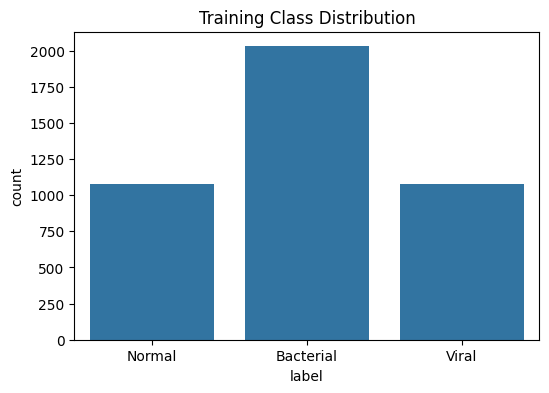

time: 620 ms (started: 2026-09-28 18:37:12 +00:00)


In [7]:
plt.figure(figsize=(6,4))

sns.countplot(data=train_df, x="label")

plt.title("Training Class Distribution")

plt.show()

##Functions

In [8]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()


def evaluate_model(model, generator, title):
    generator.reset()

    predictions = model.predict(generator, verbose=1)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes
    class_labels = list(generator.class_indices.keys())

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_labels))


def final_test_results(model, generator, verbose=0):
    test_loss, test_acc = model.evaluate(generator, verbose=0)
    print("="*30)
    print(f" FINAL TEST RESULTS ")
    print("="*30)
    print(f"Test Loss:     {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc * 100:.2f}%") # Multiplying by 100 for percentage
    print("="*30)

    results = [test_acc, 1 - test_acc]
    labels = ['Success (Correct)', 'Failure (Incorrect)']

    plt.figure(figsize=(6, 4))
    plt.bar(labels, results, color=['green', 'red'], alpha=0.7)
    plt.ylabel('Proportion')
    plt.title(f'Overall Test Accuracy: {test_acc * 100:.2f}%')
    plt.ylim(0, 1) # Scale from 0 to 100%
    for i, v in enumerate(results):
        plt.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold')
    plt.show()


def evaluate_rnn_model(model, X_test, y_test, title):
    predictions = model.predict(X_test, verbose=1)
    y_pred = np.argmax(predictions, axis=1)
    y_true = np.argmax(y_test, axis=1)

    class_labels = list(label_to_index.keys())

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_labels))



def final_test_results_rnn(X_test_patches , y_test_rnn, verbose=0):
    test_loss, test_acc = rnn_model.evaluate(X_test_patches, y_test_rnn, verbose=0)

    print("="*30)
    print(" FINAL TEST RESULTS ")
    print("="*30)
    print(f"Test Loss:     {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    print("="*30)

    results = [test_acc, 1 - test_acc]
    labels = ['Success (Correct)', 'Failure (Incorrect)']

    plt.figure(figsize=(6, 4))
    plt.bar(labels, results, color=['green', 'red'], alpha=0.7)
    plt.ylabel('Proportion')
    plt.title(f'Overall Test Accuracy: {test_acc * 100:.2f}%')
    plt.ylim(0, 1) # Scale from 0 to 100%
    for i, v in enumerate(results):
        plt.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold')
    plt.show()

time: 9.16 ms (started: 2026-09-28 18:37:12 +00:00)


##Global Parameters

In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
class_names = ['Bacterial', 'Normal', 'Viral']

time: 2.23 ms (started: 2026-09-28 18:37:13 +00:00)


#Connect to Google Drive

In [10]:
from pathlib import Path

# Local project output directories
OUTPUT_DIR = Path("outputs")

DIR_A = OUTPUT_DIR / "A-Deep_Neural_Network"
DIR_B1 = OUTPUT_DIR / "B-Transfer_Learning_Model" / "Frozen-Backbone"
DIR_B2 = OUTPUT_DIR / "B-Transfer_Learning_Model" / "Fine-tuning"
DIR_C = OUTPUT_DIR / "C-Patch-Based_and_RNN"
DIR_COMPAR = OUTPUT_DIR / "Model-Comparison"

# Create all output directories automatically
for directory in [DIR_A, DIR_B1, DIR_B2, DIR_C, DIR_COMPAR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project outputs will be saved to: {OUTPUT_DIR.resolve()}")

Project outputs will be saved to: /content/outputs
time: 2.85 ms (started: 2026-09-28 18:37:13 +00:00)


# Model A: Custom Convolutional Neural Network

## Custom CNN Architecture

The first approach uses a custom Convolutional Neural Network (CNN) trained from scratch.

Unlike the transfer-learning model introduced later, this model does not rely on pretrained features. Instead, it learns visual representations directly from the chest X-ray training data.

The network uses convolutional layers to extract spatial features, pooling layers to reduce feature-map dimensions, and fully connected layers to perform three-class classification.

This model serves as a baseline for comparison with the transfer-learning and sequence-based approaches implemented later in the project.




##Data Preprocessing & Visualisation
Resizing: Standardizing all images to
224×224
 pixels.

Normalization: Scaling pixel values from [0, 255] to [0, 1] to help the model converge faster.

Data Augmentation: Since medical data is often limited, we apply mild augmentation techniques such as small rotations, shifts, and zoom (only on the training set) to improve generalization. The transformations are intentionally kept subtle, as aggressive changes (such as large rotations or horizontal flips) may distort anatomical structures in chest X-ray images and lead to unrealistic samples.
Data Generators: Using Keras ImageDataGenerator to feed the data in batches, saving memory.

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    #shear_range=0.1,
    zoom_range=0.1,
    #horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)


time: 1 ms (started: 2026-09-28 18:37:13 +00:00)


##Data Generators
(Feeding the new split DataFrames into the generators)


In [12]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = test_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4185 validated image filenames belonging to 3 classes.
Found 1047 validated image filenames belonging to 3 classes.
Found 624 validated image filenames belonging to 3 classes.
time: 4.73 s (started: 2026-09-28 18:37:13 +00:00)


##Visualize Images

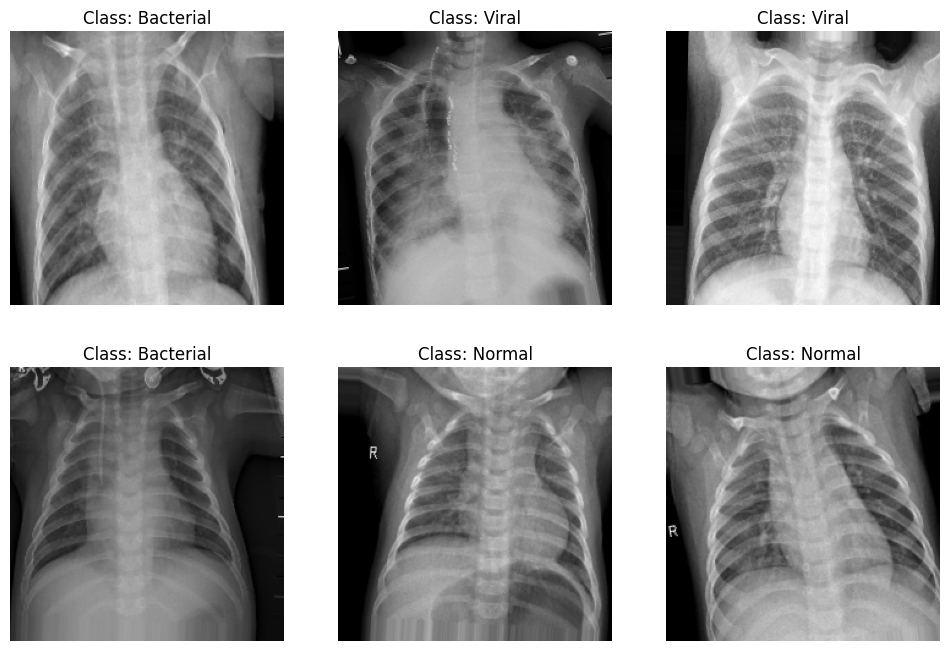

time: 9.09 s (started: 2026-09-28 18:37:17 +00:00)


In [13]:
plt.figure(figsize=(12, 8))
for i in range(6):
  img, label = next(train_generator)
  plt.subplot(2, 3, i + 1)
  plt.imshow(img[0])
  plt.title(f"Class: {list(train_generator.class_indices.keys())[np.argmax(label[0])]}")
  plt.axis('off')
plt.show()

##Custom Deep Neural Network

**Architecture Design:**



*   Convolutional Layers (Conv2D): To extract spatial features like edges and lung opacities. We'll use 3×3 filters.
*   Batch Normalization: To stabilize and speed up the training process.
* MaxPooling: To reduce the spatial dimensions and computational load.
* Dropout: To prevent overfitting (crucial since medical datasets are often small).
* Output Layer: A Dense layer with 3 neurons and a Softmax activation function for multi-class classification.




**Loss & Optimizer:**

* Loss: categorical_crossentropy (standard for 3+ classes).

* Optimizer: Adam (with a tuned learning rate).











In [14]:
tf.keras.backend.clear_session()

model = models.Sequential([
   layers.Conv2D(32, kernel_size=3, activation='relu', padding='same', input_shape=(224, 224, 3)),
   layers.BatchNormalization(),
   layers.MaxPooling2D(pool_size=2),

   layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
   layers.BatchNormalization(),
   layers.MaxPooling2D(pool_size=2),

   layers.Conv2D(128, kernel_size=3, activation='relu', padding='same'),
   layers.BatchNormalization(),
   layers.MaxPooling2D(2),

   #layers.Conv2D(256, kernel_size=3, activation='relu', padding='same'),
   #layers.BatchNormalization(),
   #layers.MaxPooling2D(pool_size=2),

   layers.Flatten(),

   layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
   layers.Dropout(0.5),
   layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


time: 3.96 s (started: 2026-09-28 18:37:26 +00:00)


In [15]:
model.compile(
    optimizer = optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics = ['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,785,283 (98.36 MB)

 Trainable params: 25,784,835 (98.36 MB)

 Non-trainable params: 448 (1.75 KB)

time: 28.3 ms (started: 2026-09-28 18:37:30 +00:00)


## Training the Custom CNN
To achieve the best results and avoid overfitting, we implement several Keras Callbacks:

* EarlyStopping: Stops training if the validation loss doesn't improve for 5 consecutive epochs. This prevents the model from "memorizing" the training data (Overfitting).

* ReduceLROnPlateau: If the learning stalls, this will automatically reduce the learning rate by a factor (e.g., 0.2), allowing the model to make smaller, more precise "steps" towards the optimum.

* ModelCheckpoint: Saves only the best version of our model (the one with the lowest validation loss).

Since the dataset is imbalanced across the three classes, relying on standard accuracy alone may lead to biased predictions toward the majority class. To address this, we compute class weights based on the training data and incorporate them during training. This ensures that errors on underrepresented classes (such as Viral pneumonia) are penalized more, encouraging the model to learn a more balanced decision boundary.

In [16]:
weight = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(weight))

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        mode='max',
        factor=0.2,
        patience=2,
        min_lr=1e-5,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(DIR_A, 'best_cnn_model.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

time: 5.54 ms (started: 2026-09-28 18:37:30 +00:00)


In [17]:
history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 20,
    callbacks = callbacks,
    class_weight = class_weights
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 869ms/step - accuracy: 0.5701 - loss: 2.2713
Epoch 1: val_accuracy improved from None to 0.25692, saving model to outputs/A-Deep_Neural_Network/best_cnn_model.keras

Epoch 1: finished saving model to outputs/A-Deep_Neural_Network/best_cnn_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.6241 - loss: 1.3380 - val_accuracy: 0.2569 - val_loss: 9.1168 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - accuracy: 0.6734 - loss: 0.7732
Epoch 2: val_accuracy did not improve from 0.25692
131/131 ━━━━━━━━━━━━━━━━━━━━ 100s 766ms/step - accuracy: 0.6817 - loss: 0.7646 - val_accuracy: 0.2569 - val_loss: 7.0594 - learning_rate: 1.0000e-04
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - accuracy: 0.6902 - loss: 0.7632
Epoch 3: val_accuracy improved from 0.25692 to 0.50812, saving model to outputs/A-Deep_Neural_Network/best_cnn_model.keras

Epoch 3: finished saving model to outputs/A-Deep_Neural_Netw

### Saving the Trained Model and Training History

After training, the model weights, complete Keras model, and epoch-by-epoch training history are saved for reproducibility and later comparison with the other architectures.

In [18]:
model.save_weights(os.path.join(DIR_A,'winning_cnn_weights.weights.h5'))
model.save(os.path.join(DIR_A,'cnn_model.keras'))
history_CNN_df = pd.DataFrame(history.history)
history_CNN_df.to_csv(os.path.join(DIR_A,'history_cnn.csv'), index=False)


time: 10.9 s (started: 2026-09-28 18:57:44 +00:00)


## Custom CNN Evaluation

The trained CNN is evaluated on the held-out test set using multiple metrics rather than accuracy alone.

Evaluation includes:

- Test loss and accuracy
- Confusion matrix
- Precision, recall, and F1-score for each class
- Training and validation curves

These metrics provide a more complete view of the model's performance across Normal, Bacterial Pneumonia, and Viral Pneumonia cases.

### Training Performance Visualization

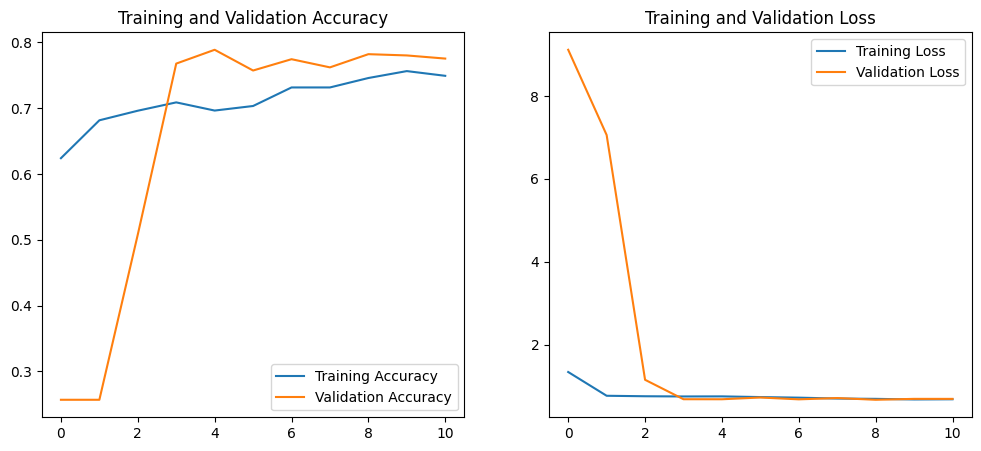

time: 267 ms (started: 2026-09-28 18:57:55 +00:00)


In [19]:
# Plotting Accuracy and Loss
plot_history(history)

###Model Evaluation on Test Set
Now we evaluate our custom model using the Test Set. This is the most critical part of the project.

**Metrics used:**

* Confusion Matrix: Shows exactly how many images were correctly classified and where the model "got confused" (e.g., mistaking Bacterial for Viral).

* Classification Report: Provides Precision, Recall, and F1-Score for each class.

  * Crucial note: In medical diagnosis, high Recall for pneumonia is vital because we don't want to miss a sick patient (False Negative).

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 403ms/step


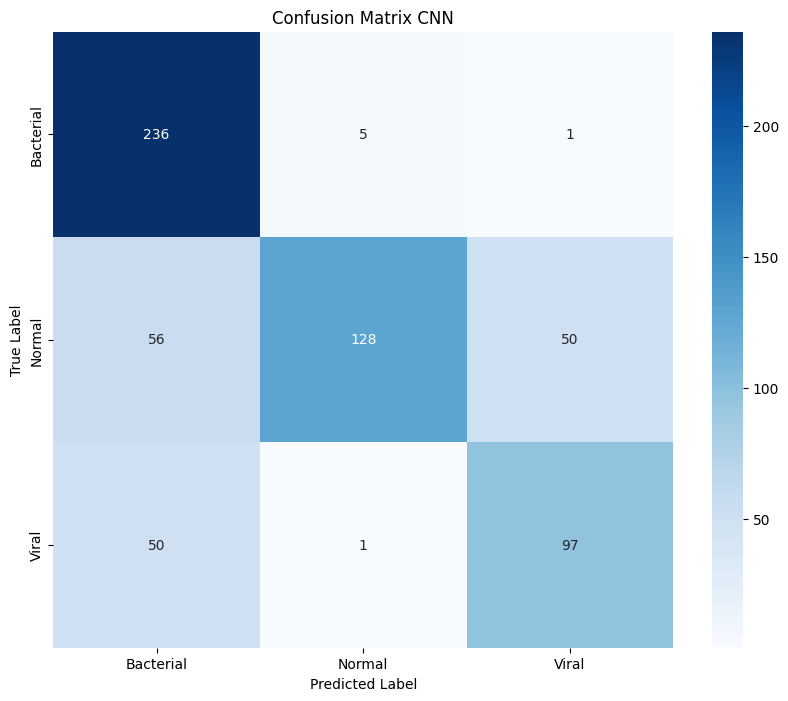


Classification Report:
              precision    recall  f1-score   support

   Bacterial       0.69      0.98      0.81       242
      Normal       0.96      0.55      0.70       234
       Viral       0.66      0.66      0.66       148

    accuracy                           0.74       624
   macro avg       0.77      0.73      0.72       624
weighted avg       0.78      0.74      0.73       624

time: 10.1 s (started: 2026-09-28 18:57:55 +00:00)


In [20]:
evaluate_model(model, test_generator, 'Confusion Matrix CNN')

 FINAL TEST RESULTS 
Test Loss:     0.9793
Test Accuracy: 73.88%


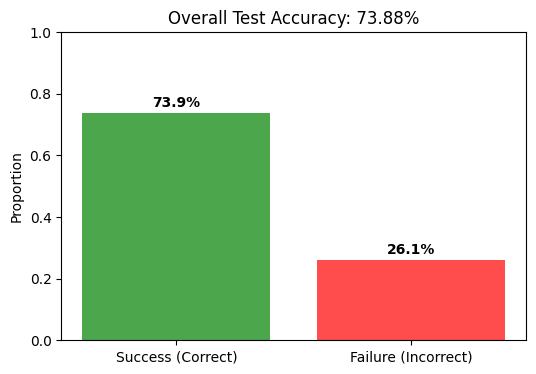

time: 7.06 s (started: 2026-09-28 18:58:05 +00:00)


In [21]:
final_test_results(model, test_generator, 0)

# Model B: EfficientNetB0 Transfer Learning

## Transfer Learning Approach

The second approach uses **EfficientNetB0**, pretrained on ImageNet, as a feature extractor for chest X-ray classification.

Training is performed in two stages:

1. **Frozen Backbone:** The pretrained EfficientNetB0 layers are initially frozen while the new classification head is trained on the chest X-ray dataset.
2. **Fine-Tuning:** Selected layers of the pretrained network are then unfrozen and trained with a lower learning rate to adapt the learned features to the medical imaging task.

This approach evaluates whether transfer learning can improve classification performance compared with the custom CNN trained from scratch.

##Data Preprocessing for Transfer Learning

In [22]:
train_datagen_b = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=6,
    width_shift_range=0.03,
    height_shift_range=0.03,
    zoom_range=0.05,
    fill_mode='nearest'
)

test_datagen_b = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

time: 1.18 ms (started: 2026-09-28 18:58:12 +00:00)


##Data Generators

In [23]:
train_generator_b = train_datagen_b.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=class_names
)

val_generator_b = test_datagen_b.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=class_names,
    shuffle=False
)

test_generator_b = test_datagen_b.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=class_names,
    shuffle=False
)

Found 4185 validated image filenames belonging to 3 classes.
Found 1047 validated image filenames belonging to 3 classes.
Found 624 validated image filenames belonging to 3 classes.
time: 1.24 s (started: 2026-09-28 18:58:12 +00:00)


# Training Strategy: Frozen Backbone vs Fine-Tuning

We follow a two-stage training strategy commonly used in transfer learning.

In the first stage, we freeze all layers of the pre-trained EfficientNet backbone and train only a new classification head. This allows the model to adapt to the new task without modifying the learned feature representations.

In the second stage, we partially unfreeze the upper layers of the backbone and fine-tune them using a smaller learning rate. The higher layers are more task-specific, so fine-tuning them helps the model better adapt to the X-ray domain while preserving useful low-level features learned from ImageNet.

##Phase 1: Training with Frozen Backbone

###Building the Transfer Learning Model

In [24]:
tf.keras.backend.clear_session()

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False #freezing all layers

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
time: 4.59 s (started: 2026-09-28 18:58:14 +00:00)


In [25]:
tl_model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),

    layers.Dense(3, activation='softmax')
])

time: 70 ms (started: 2026-09-28 18:58:18 +00:00)


In [26]:
tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

time: 16.1 ms (started: 2026-09-28 18:58:18 +00:00)


##Training Monitoring

In [27]:
weight_b = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator_b.classes),
    y=train_generator_b.classes
)

class_weights_b = dict(enumerate(weight_b))

callbacks_b1 = [
    EarlyStopping(
        monitor='val_accuracy',
        mode='max',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        mode='max',
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(DIR_B1, 'best_transfer_frozen.keras'),
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

time: 5.09 ms (started: 2026-09-28 18:58:18 +00:00)


In [28]:
history_tl_frozen = tl_model.fit(
    train_generator_b,
    epochs=20,
    validation_data=val_generator_b,
    class_weight=class_weights_b,
    callbacks=callbacks_b1,
    verbose=1
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 868ms/step - accuracy: 0.5295 - loss: 1.2161
Epoch 1: val_accuracy improved from None to 0.63515, saving model to outputs/B-Transfer_Learning_Model/Frozen-Backbone/best_transfer_frozen.keras

Epoch 1: finished saving model to outputs/B-Transfer_Learning_Model/Frozen-Backbone/best_transfer_frozen.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.5787 - loss: 1.1007 - val_accuracy: 0.6351 - val_loss: 0.8958 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.6221 - loss: 0.9817
Epoch 2: val_accuracy improved from 0.63515 to 0.69914, saving model to outputs/B-Transfer_Learning_Model/Frozen-Backbone/best_transfer_frozen.keras

Epoch 2: finished saving model to outputs/B-Transfer_Learning_Model/Frozen-Backbone/best_transfer_frozen.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 100s 763ms/step - accuracy: 0.6282 - loss: 0.9406 - val_accuracy: 0.6991 - val_loss: 0.7726 - learning_rate: 1.0000e-04
Epoch 3/20

### Saving the Model and Training History

In [29]:
tl_model.save_weights(os.path.join(DIR_B1,'frozen_backbone_weights.weights.h5'))
tl_model.save(os.path.join(DIR_B1,'frozen_backbone_model.keras'))
history_frozen_df = pd.DataFrame(history_tl_frozen.history)
history_frozen_df.to_csv(os.path.join(DIR_B1,'history_frozen.csv'), index=False)

time: 1.29 s (started: 2026-09-28 19:30:13 +00:00)


###Visualizing Results

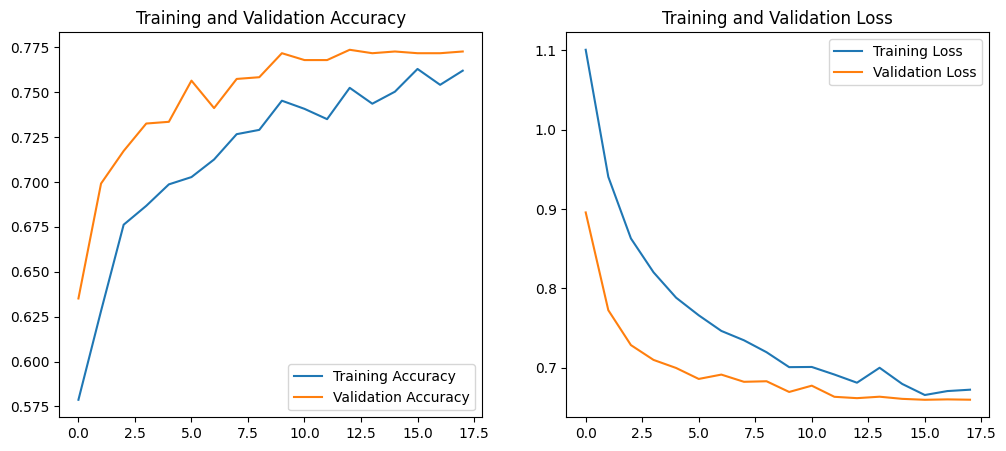

time: 294 ms (started: 2026-09-28 19:30:14 +00:00)


In [30]:
plot_history(history_tl_frozen)

20/20 ━━━━━━━━━━━━━━━━━━━━ 27s 979ms/step


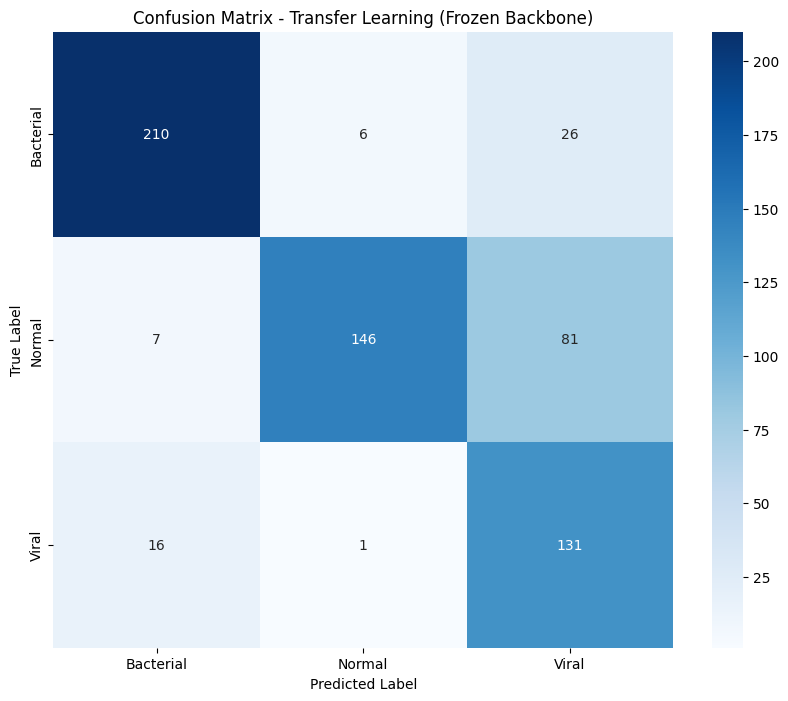


Classification Report:
              precision    recall  f1-score   support

   Bacterial       0.90      0.87      0.88       242
      Normal       0.95      0.62      0.75       234
       Viral       0.55      0.89      0.68       148

    accuracy                           0.78       624
   macro avg       0.80      0.79      0.77       624
weighted avg       0.84      0.78      0.79       624

time: 28.3 s (started: 2026-09-28 19:30:15 +00:00)


In [31]:
evaluate_model(tl_model, test_generator_b, 'Confusion Matrix - Transfer Learning (Frozen Backbone)')

 FINAL TEST RESULTS 
Test Loss:     0.7569
Test Accuracy: 78.04%


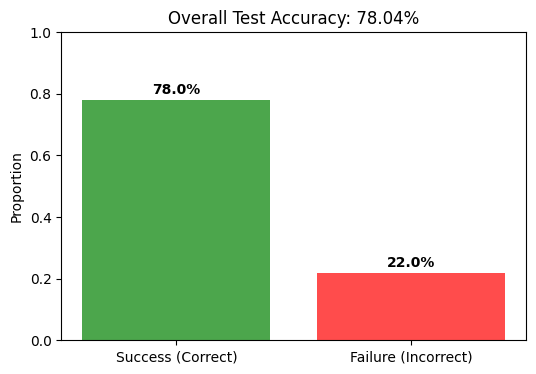

time: 12.1 s (started: 2026-09-28 19:30:43 +00:00)


In [32]:
final_test_results(tl_model, test_generator_b, 0)

## Phase 2: Fine-Tuning

After training the classification head, part of the EfficientNetB0 backbone is unfrozen for fine-tuning.

The model is trained using a lower learning rate, allowing the pretrained features to adapt more gradually to the chest X-ray domain while reducing the risk of disrupting useful representations learned during ImageNet pretraining.

In [33]:
tl_model = keras.models.load_model(os.path.join(DIR_B1, 'frozen_backbone_model.keras'))
base_model = tl_model.layers[0]

base_model.trainable = True

for layer in base_model.layers[:-50]: # need to do equ - 3,20,50,100,120
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=3e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

time: 1.46 s (started: 2026-09-28 19:30:55 +00:00)


##Training Monitoring

In [34]:
callbacks_b2 = [
    EarlyStopping(monitor='val_accuracy', mode='max', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.2, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint(os.path.join(DIR_B2,'best_transfer_finetune.keras'), monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)
]

time: 625 µs (started: 2026-09-28 19:30:56 +00:00)


In [35]:
history_tl_finetune = tl_model.fit(
    train_generator_b,
    epochs=20,
    validation_data=val_generator_b,
    class_weight=class_weights_b,
    callbacks=callbacks_b2,
    verbose=1
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 822ms/step - accuracy: 0.7509 - loss: 0.6845
Epoch 1: val_accuracy improved from None to 0.77364, saving model to outputs/B-Transfer_Learning_Model/Fine-tuning/best_transfer_finetune.keras

Epoch 1: finished saving model to outputs/B-Transfer_Learning_Model/Fine-tuning/best_transfer_finetune.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.7568 - loss: 0.6856 - val_accuracy: 0.7736 - val_loss: 0.6593 - learning_rate: 3.0000e-06
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.7622 - loss: 0.6674
Epoch 2: val_accuracy did not improve from 0.77364
131/131 ━━━━━━━━━━━━━━━━━━━━ 102s 775ms/step - accuracy: 0.7584 - loss: 0.6693 - val_accuracy: 0.7698 - val_loss: 0.6609 - learning_rate: 3.0000e-06
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.7479 - loss: 0.6984
Epoch 3: val_accuracy improved from 0.77364 to 0.77459, saving model to outputs/B-Transfer_Learning_Model/Fine-tuning/best_transfer_fine

### Saving the Model and Training History

In [36]:
tl_model.save_weights(os.path.join(DIR_B2,'finetuned_weight.weights.h5'))
tl_model.save(os.path.join(DIR_B2,'finetuned_model.keras'))
history_finetune_df = pd.DataFrame(history_tl_finetune.history)
history_finetune_df.to_csv(os.path.join(DIR_B2,'history_finetune.csv'), index=False)

time: 1.41 s (started: 2026-09-28 19:49:05 +00:00)


## EfficientNetB0 Evaluation

The fine-tuned EfficientNetB0 model is evaluated on the held-out test set to assess its performance on unseen chest X-ray images.

Evaluation includes training and validation behavior, test accuracy, confusion matrix analysis, and class-specific precision, recall, and F1-score.

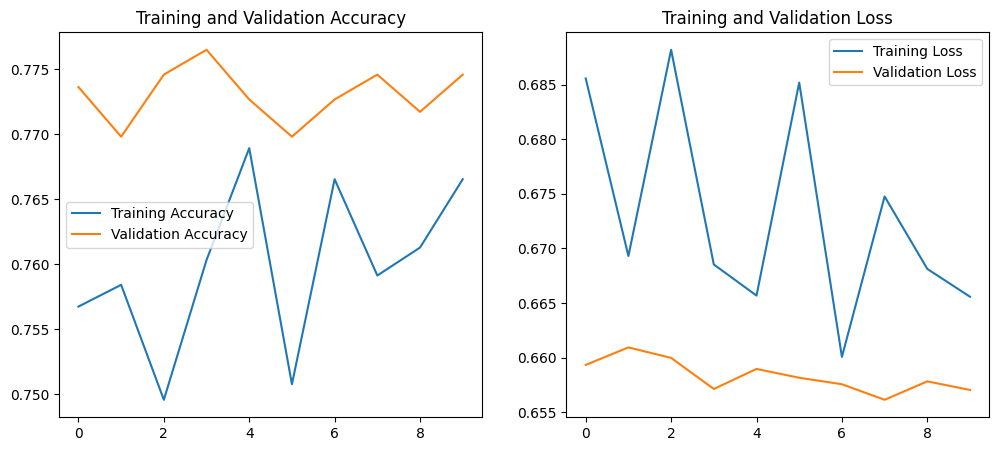

time: 289 ms (started: 2026-09-28 19:49:07 +00:00)


In [37]:
plot_history(history_tl_finetune)

20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 631ms/step


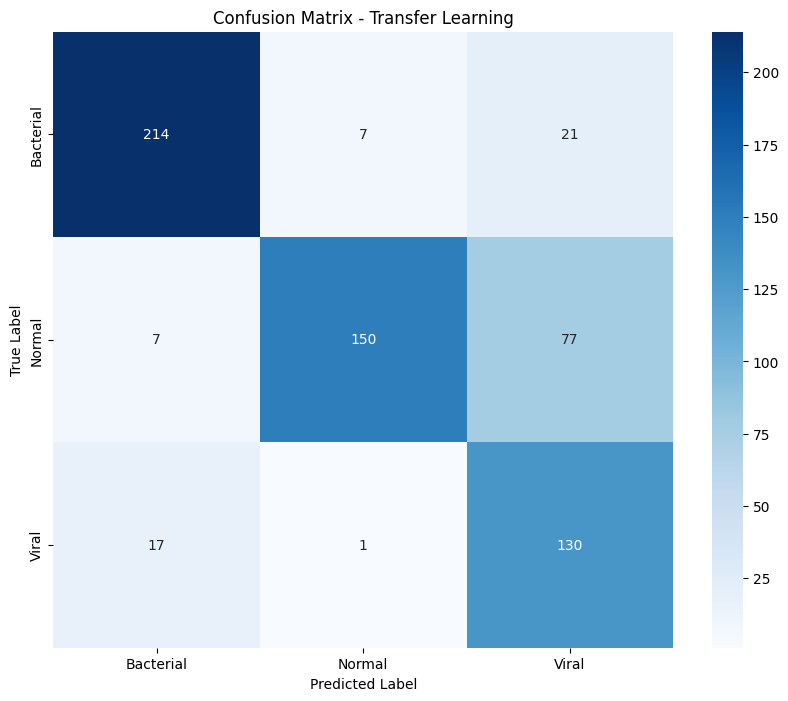


Classification Report:
              precision    recall  f1-score   support

   Bacterial       0.90      0.88      0.89       242
      Normal       0.95      0.64      0.77       234
       Viral       0.57      0.88      0.69       148

    accuracy                           0.79       624
   macro avg       0.81      0.80      0.78       624
weighted avg       0.84      0.79      0.80       624

time: 21.3 s (started: 2026-09-28 19:49:07 +00:00)


In [38]:
evaluate_model(tl_model, test_generator_b, 'Confusion Matrix - Transfer Learning')

 FINAL TEST RESULTS 
Test Loss:     0.7458
Test Accuracy: 79.17%


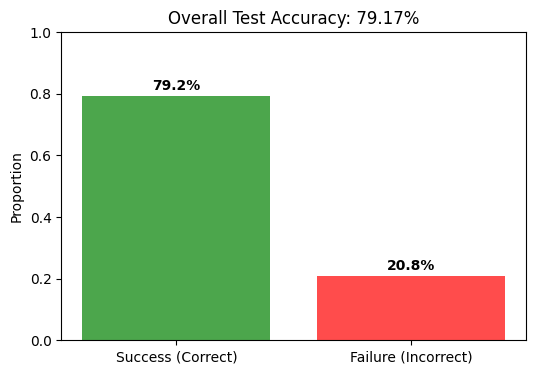

time: 12 s (started: 2026-09-28 19:49:28 +00:00)


In [39]:
final_test_results(tl_model, test_generator_b, 0)

# Model C: Patch-Based Bidirectional GRU








## Patch-Based Sequence Modeling

The third approach explores a different representation of chest X-ray images by treating each image as a sequence of smaller patches.

Instead of processing the full image exclusively through convolutional layers, the image is divided into patches and transformed into a sequential representation.

A **Bidirectional Gated Recurrent Unit (BiGRU)** network then processes this sequence in both forward and backward directions, allowing the model to capture relationships between different regions of the image.

This approach provides an alternative to the convolution-based models and enables comparison between spatial feature extraction and sequence-based image modeling.

##Loading Images for the RNN Pipeline
Since the RNN model requires array-based input, we load the images directly from the DataFrames and convert them into NumPy arrays.
Each image is resized to 224×224 and normalized to the range [0,1].

In [40]:
PATCH_SIZE = 16
NUM_CLASSES = 3

label_to_index = train_generator.class_indices
index_to_label = {v: k for k, v in label_to_index.items()}

def load_images_from_dataframe(df, target_size=IMG_SIZE):
    images = []
    labels = []

    for _, row in df.iterrows():
        img = keras.utils.load_img(row['image_path'], color_mode='grayscale', target_size=target_size)
        img = keras.utils.img_to_array(img)
        img = img / 255.0

        images.append(img)
        labels.append(label_to_index[row['label']]) #vec of class label e.g. [1 , 0 , 2 , 2 , 1 ,.....]

    X = np.array(images, dtype=np.float32)
    y = keras.utils.to_categorical(labels, num_classes=NUM_CLASSES)  #one hot encoding
    '''
    e.g.
    0 -> [1, 0, 0]
    1 -> [0, 1, 0]
    2 -> [0, 0, 1]
    '''

    return X, y

X_train_rnn, y_train_rnn = load_images_from_dataframe(train_df)
X_val_rnn, y_val_rnn = load_images_from_dataframe(val_df)
X_test_rnn, y_test_rnn = load_images_from_dataframe(test_df)

print("X_train_rnn shape:", X_train_rnn.shape)
print("y_train_rnn shape:", y_train_rnn.shape)
print("X_val_rnn shape:", X_val_rnn.shape)
print("y_val_rnn shape:", y_val_rnn.shape)
print("X_test_rnn shape:", X_test_rnn.shape)
print("y_test_rnn shape:", y_test_rnn.shape)

X_train_rnn shape: (4185, 224, 224, 1)
y_train_rnn shape: (4185, 3)
X_val_rnn shape: (1047, 224, 224, 1)
y_val_rnn shape: (1047, 3)
X_test_rnn shape: (624, 224, 224, 1)
y_test_rnn shape: (624, 3)
time: 39.1 s (started: 2026-09-28 19:49:40 +00:00)


##Converting Images into Patch Sequences

In [41]:
def images_to_patch_sequences(X, patch_size=PATCH_SIZE):
    num_samples, img_h, img_w, channels = X.shape

    patches_per_row = img_w // patch_size
    patches_per_col = img_h // patch_size
    num_patches = patches_per_row * patches_per_col
    patch_dim = patch_size * patch_size * channels

    X_reshaped = X.reshape(
        num_samples,
        patches_per_col,
        patch_size,
        patches_per_row,
        patch_size,
        channels
    )

    X_reshaped = X_reshaped.transpose(0, 1, 3, 2, 4, 5)

    X_patches = X_reshaped.reshape(
        num_samples,
        num_patches,
        patch_dim
    )

    return X_patches

X_train_patches = images_to_patch_sequences(X_train_rnn)
X_val_patches = images_to_patch_sequences(X_val_rnn)
X_test_patches = images_to_patch_sequences(X_test_rnn)

print("X_train_patches shape:", X_train_patches.shape)
print("X_val_patches shape:", X_val_patches.shape)
print("X_test_patches shape:", X_test_patches.shape)


#free memory
del X_train_rnn
del X_val_rnn
del X_test_rnn

gc.collect()

X_train_patches shape: (4185, 196, 256)
X_val_patches shape: (1047, 196, 256)
X_test_patches shape: (624, 196, 256)


3857

time: 2.35 s (started: 2026-09-28 19:50:19 +00:00)


##Building the RNN Model

In [42]:
rnn_model = models.Sequential([
    layers.Input(shape=(X_train_patches.shape[1], X_train_patches.shape[2])),

    layers.Bidirectional(
        layers.GRU(64, return_sequences=False),
        name="bidirectional_gru"
    ),

    layers.Dense(128, activation='relu', name="rnn_dense_128"),
    layers.Dropout(0.3, name="rnn_dropout_1"),

    layers.Dense(64, activation='relu', name="rnn_dense_64"),
    layers.Dropout(0.3, name="rnn_dropout_2"),

    layers.Dense(3, activation='softmax', name="rnn_output")
])

time: 208 ms (started: 2026-09-28 19:50:22 +00:00)


In [43]:
rnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_gru               │ (None, 128)            │       123,648 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_dense_128 (Dense)           │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_dropout_1 (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_dense_64 (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_dropout_2 (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_output (Dense)              │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,611 (580.51 KB)

 Trainable params: 148,611 (580.51 KB)

 Non-trainable params: 0 (0.00 B)

time: 20.4 ms (started: 2026-09-28 19:50:22 +00:00)


##Training the RNN Model

In [44]:
weight_c = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(np.argmax(y_train_rnn, axis=1)),
    y=np.argmax(y_train_rnn, axis=1)
)

class_weights_c = dict(enumerate(weight_c))

callbacks_c = [
    EarlyStopping(monitor='val_accuracy', mode='max', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.2, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint(os.path.join(DIR_C,'best_patch_rnn.keras'),  monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)
]

time: 5.28 ms (started: 2026-09-28 19:50:22 +00:00)


In [45]:
print(label_to_index)
class_weights_c[1] *= 1.5

{'Bacterial': 0, 'Normal': 1, 'Viral': 2}
time: 1.11 ms (started: 2026-09-28 19:50:22 +00:00)


In [46]:
history_rnn = rnn_model.fit(
    X_train_patches,
    y_train_rnn,
    validation_data=(X_val_patches, y_val_rnn),
    epochs=40,
    batch_size=32,
    class_weight=class_weights_c,
    callbacks=callbacks_c,
    verbose=1
)

Epoch 1/40
129/131 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.2920 - loss: 1.2719
Epoch 1: val_accuracy improved from None to 0.28080, saving model to outputs/C-Patch-Based_and_RNN/best_patch_rnn.keras

Epoch 1: finished saving model to outputs/C-Patch-Based_and_RNN/best_patch_rnn.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.2963 - loss: 1.2577 - val_accuracy: 0.2808 - val_loss: 1.1115 - learning_rate: 1.0000e-04
Epoch 2/40
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3664 - loss: 1.2140
Epoch 2: val_accuracy improved from 0.28080 to 0.45845, saving model to outputs/C-Patch-Based_and_RNN/best_patch_rnn.keras

Epoch 2: finished saving model to outputs/C-Patch-Based_and_RNN/best_patch_rnn.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3969 - loss: 1.2022 - val_accuracy: 0.4585 - val_loss: 1.0491 - learning_rate: 1.0000e-04
Epoch 3/40
130/131 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5010 - loss: 1.1334
Epoch 3: val_accuracy improved 

### Saving the Model and Training History

In [47]:
rnn_model.save_weights(os.path.join(DIR_C, 'rnn_weights.weights.h5'))
rnn_model.save(os.path.join(DIR_C, 'rnn_model.keras'))
history_rnn_df = pd.DataFrame(history_rnn.history)
history_rnn_df.to_csv(os.path.join(DIR_C, 'history_rnn.csv'), index=False)

time: 112 ms (started: 2026-09-28 19:51:33 +00:00)


## Bidirectional GRU Evaluation

The trained patch-based Bidirectional GRU model is evaluated on the held-out test set using the same evaluation framework applied to the previous models.

Performance is assessed using test accuracy, training and validation behavior, confusion matrix analysis, and class-specific precision, recall, and F1-score.

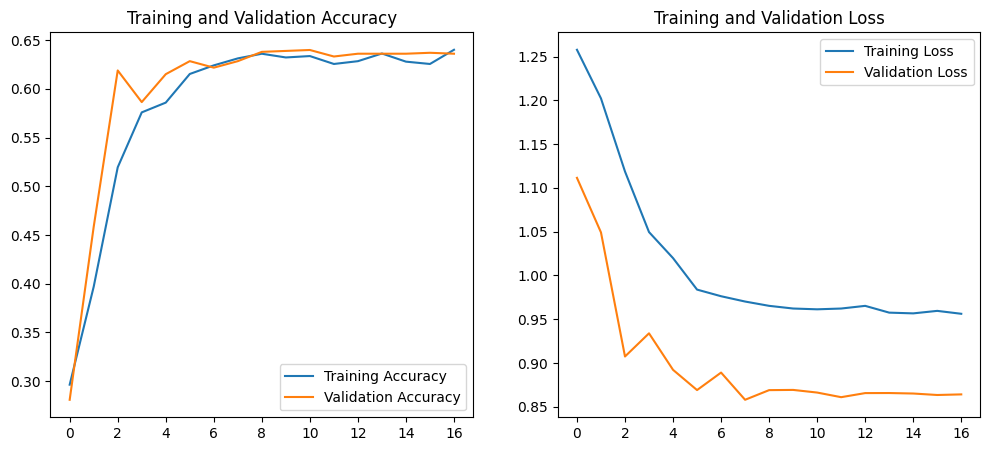

time: 345 ms (started: 2026-09-28 19:51:33 +00:00)


In [48]:
plot_history(history_rnn)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


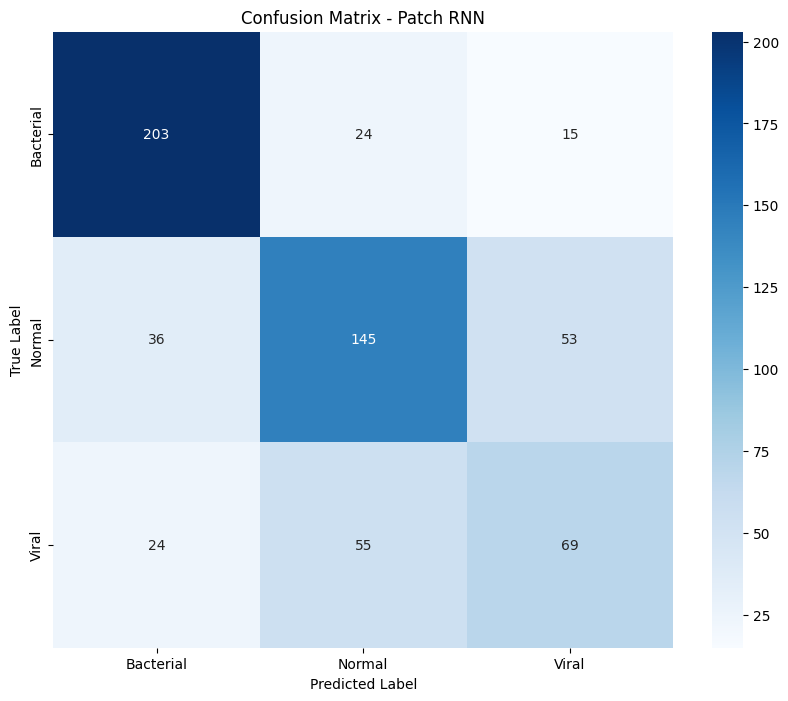


Classification Report:
              precision    recall  f1-score   support

   Bacterial       0.77      0.84      0.80       242
      Normal       0.65      0.62      0.63       234
       Viral       0.50      0.47      0.48       148

    accuracy                           0.67       624
   macro avg       0.64      0.64      0.64       624
weighted avg       0.66      0.67      0.66       624

time: 1.06 s (started: 2026-09-28 19:51:34 +00:00)


In [49]:
evaluate_rnn_model(rnn_model, X_test_patches, y_test_rnn, 'Confusion Matrix - Patch RNN')

 FINAL TEST RESULTS 
Test Loss:     0.8997
Test Accuracy: 66.83%


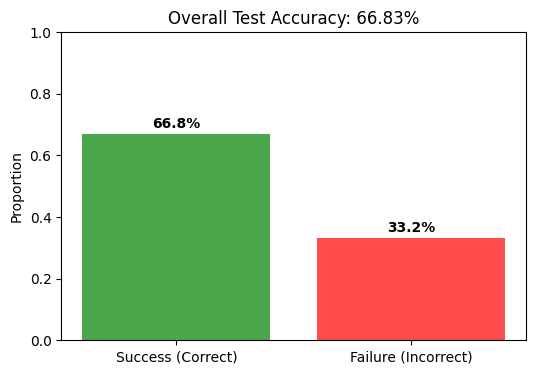

time: 680 ms (started: 2026-09-28 19:51:35 +00:00)


In [50]:
final_test_results_rnn(X_test_patches, y_test_rnn, )

# Model Comparison

The three modeling approaches are compared using their recorded training histories and held-out test-set performance.

The comparison includes:

- **Custom CNN**, trained from scratch
- **EfficientNetB0 with a frozen backbone**
- **EfficientNetB0 after fine-tuning**
- **Patch-Based Bidirectional GRU**

Training and validation accuracy and loss are examined alongside test-set evaluation metrics to compare the behavior and generalization of each approach.

##Load Saved Training Histories

In [51]:
history_cnn_df = pd.read_csv(os.path.join(DIR_A, 'history_cnn.csv'))
history_frozen_df = pd.read_csv(os.path.join(DIR_B1, 'history_frozen.csv'))
history_finetune_df = pd.read_csv(os.path.join(DIR_B2, 'history_finetune.csv'))
history_rnn_df = pd.read_csv(os.path.join(DIR_C, 'history_rnn.csv'))

time: 9.73 ms (started: 2026-09-28 19:51:35 +00:00)


##Validation Accuracy Comparison
This graph shows how well each model performs on unseen validation data


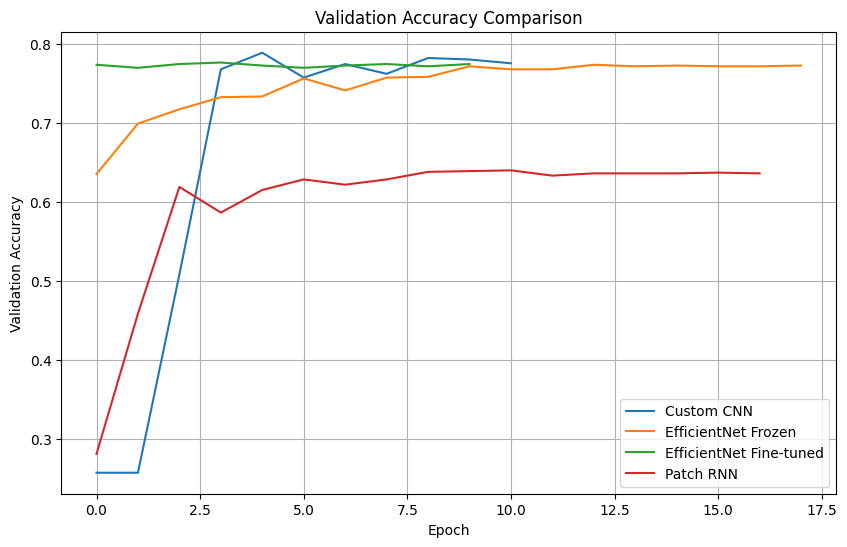

time: 206 ms (started: 2026-09-28 19:51:35 +00:00)


In [52]:
plt.figure(figsize=(10,6))

plt.plot(history_cnn_df['val_accuracy'], label='Custom CNN')
plt.plot(history_frozen_df['val_accuracy'], label='EfficientNet Frozen')
plt.plot(history_finetune_df['val_accuracy'], label='EfficientNet Fine-tuned')
plt.plot(history_rnn_df['val_accuracy'], label='Patch RNN')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

##Validation Loss Comparison
This graph helps detect overfitting and training stability


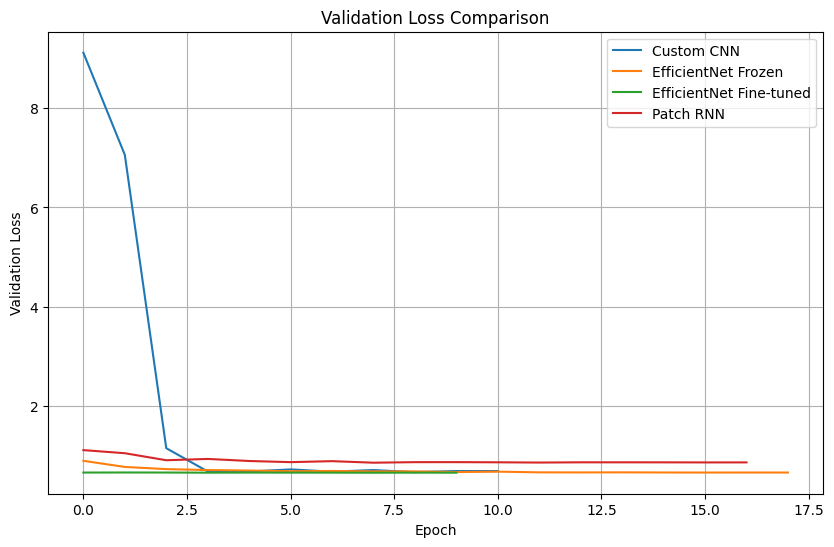

time: 181 ms (started: 2026-09-28 19:51:36 +00:00)


In [53]:
plt.figure(figsize=(10,6))

plt.plot(history_cnn_df['val_loss'], label='Custom CNN')
plt.plot(history_frozen_df['val_loss'], label='EfficientNet Frozen')
plt.plot(history_finetune_df['val_loss'], label='EfficientNet Fine-tuned')
plt.plot(history_rnn_df['val_loss'], label='Patch RNN')

plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


##Training Accuracy Comparison
Show how well each model learned the training data

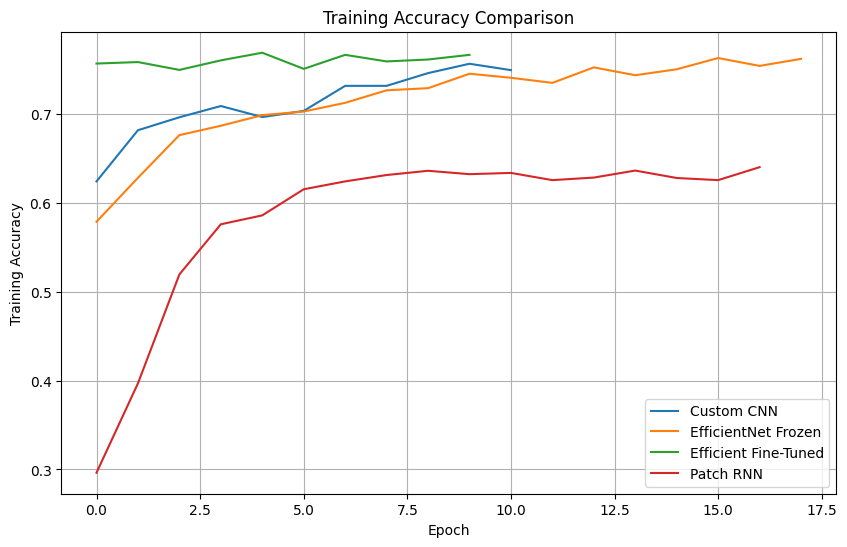

time: 184 ms (started: 2026-09-28 19:51:36 +00:00)


In [54]:
plt.figure(figsize=(10,6))

plt.plot(history_cnn_df['accuracy'], label='Custom CNN')
plt.plot(history_frozen_df['accuracy'], label='EfficientNet Frozen'),
plt.plot(history_finetune_df['accuracy'], label='Efficient Fine-Tuned'),
plt.plot(history_rnn_df['accuracy'], label='Patch RNN')

plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.legend()
plt.grid(True)
plt.show()

##Test Accuracy Comparison - final metric


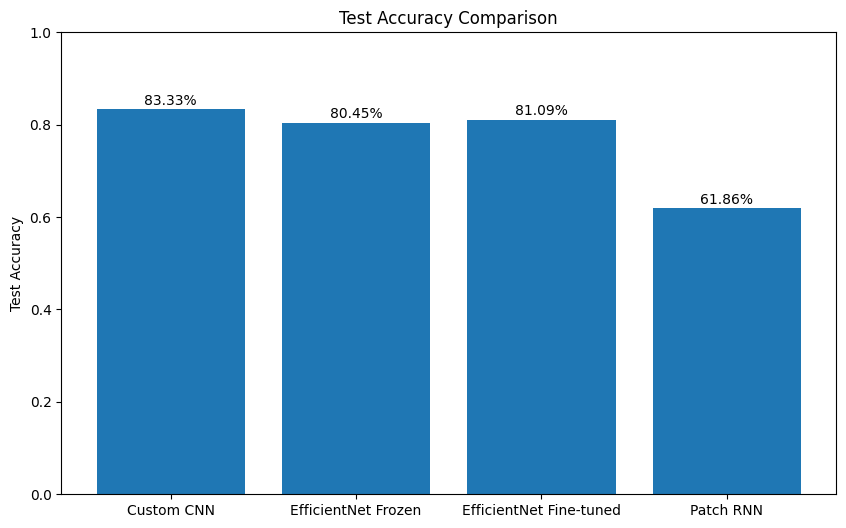

time: 121 ms (started: 2026-09-28 19:51:36 +00:00)


In [55]:
model_names = [
    'Custom CNN',
    'EfficientNet Frozen',
    'EfficientNet Fine-tuned',
    'Patch RNN'
]

test_accuracies = [
    0.8333, #CNN
    0.8045, #Frozen
    0.8109, #Fine-tuned
    0.6186   #RNN
]

plt.figure(figsize=(10,6))
bars = plt.bar(model_names, test_accuracies)

plt.title('Test Accuracy Comparison')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)

for bar, acc in zip(bars, test_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f'{acc*100:.2f}%', ha='center')

plt.show()

##Summary Table
this table summarizes the perfornance of all models

In [56]:
comparison_df = pd.DataFrame({
    'Model': model_names,

    'Best Train Accuracy': [
        history_cnn_df['accuracy'].max(),
        history_frozen_df['accuracy'].max(),
        history_finetune_df['accuracy'].max(),
        history_rnn_df['accuracy'].max()
    ],

    'Best Validation Accuracy': [
        history_cnn_df['val_accuracy'].max(),
        history_frozen_df['val_accuracy'].max(),
        history_finetune_df['val_accuracy'].max(),
        history_rnn_df['val_accuracy'].max()
    ],

    'Lowest Validation Loss': [
        history_cnn_df['val_loss'].min(),
        history_frozen_df['val_loss'].min(),
        history_finetune_df['val_loss'].min(),
        history_rnn_df['val_loss'].min()
    ],

    'Test Accuracy': test_accuracies
})

comparison_df

,Model,Best Train Accuracy,Best Validation Accuracy,Lowest Validation Loss,Test Accuracy
0,Custom CNN,0.756511,0.788921,0.667779,0.8333
1,EfficientNet Frozen,0.762963,0.773639,0.659791,0.8045
2,EfficientNet Fine-tuned,0.768937,0.776504,0.656131,0.8109
3,Patch RNN,0.640143,0.639924,0.858038,0.6186


time: 24 ms (started: 2026-09-28 19:51:36 +00:00)


##Save Comparison Table

In [57]:
comparison_df.to_csv(
    os.path.join(DIR_COMPAR, 'model_comparison.csv'),
    index=False)

time: 1.89 ms (started: 2026-09-28 19:51:36 +00:00)


# Conclusion

This project explored three deep learning strategies for multi-class chest X-ray classification: a custom Convolutional Neural Network, EfficientNetB0 transfer learning, and a patch-based Bidirectional GRU.

Each approach represents a different modeling strategy. The custom CNN learns image features directly from the training data, EfficientNetB0 leverages pretrained visual representations through transfer learning and fine-tuning, and the Bidirectional GRU treats image patches as a sequence to capture relationships across different image regions.

The models were evaluated on a held-out test set using accuracy, confusion matrices, and class-specific precision, recall, and F1-score. Comparing these results highlights the differences in training behavior and generalization across the three architectures.

The project demonstrates an end-to-end deep learning workflow including dataset preparation, class balancing, model development, transfer learning, sequence-based modeling, training monitoring, and comparative evaluation.

## Limitations and Future Work

Several extensions could strengthen the project further:

- Evaluate the models on additional external chest X-ray datasets.
- Explore additional data augmentation and regularization strategies.
- Investigate model explainability techniques such as Grad-CAM.
- Perform systematic hyperparameter optimization.
- Evaluate additional pretrained architectures and ensemble approaches.
- Analyze class-specific errors in greater detail.

> **Note:** This project was developed for educational and research purposes. The models are not intended for clinical diagnosis or medical decision-making.